# Questionnair Analysis

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import os
import re
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from load_data import load_data_file, load_data_directory

## Load Data

In [2]:
households = pd.read_csv('data/Questionnaires/Household Questionnaire (Responses) - Form Responses 1.csv')
indoor_air_quality_health = pd.read_csv('data/Questionnaires/Indoor Air Quality & Health Check-In (Responses) - Form Responses 1.csv')

# Drop identifying columns if present in the files
households = households.drop(columns=['Enter Your Name Here\n', 'Enter your College Email:'], errors='ignore')
indoor_air_quality_health = indoor_air_quality_health.drop(columns=['Enter Your Name:', 'Enter Your College Email:'], errors='ignore')

## Make Plots

In [3]:
def _safe_filename(text, max_len=150):
    text = str(text).strip()
    text = re.sub(r'[<>:\\"/\\|?*\r\n\t]+', '_', text)
    text = re.sub(r'\s+', '_', text)
    text = re.sub(r'_+', '_', text).strip('._')
    if not text:
        text = 'unnamed_column'
    return text[:max_len]


def make_pi_plots(data=None, data_name=None):
    if data is None:
        raise ValueError("Data must be provided for plotting.")
    if data_name is None:
        raise ValueError("Data name must be provided for plot titles.")

    # Create plots directory if it doesn't exist
    output_dir = os.path.join("data", "Questionnaires", "Plots", data_name)
    os.makedirs(output_dir, exist_ok=True)

    # Loop through each column in the DataFrame
    for column in data.columns:
        # Skip timestamp column if it exists
        if str(column).strip().lower() == 'timestamp':
            continue

        # Include missing values as a category and convert labels to string
        value_counts = data[column].fillna("Missing").astype(str).value_counts()
        if value_counts.empty:
            print(f"Skipped empty column: {data_name} - {column}")
            continue

        # Create pie chart
        plt.figure(figsize=(8, 8))
        plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=140)
        plt.title(f'{data_name} - {column}')
        plt.axis('equal')

        # Save plot with a Windows-safe file name
        column_safe = _safe_filename(column)
        save_path = os.path.join(output_dir, f"{column_safe}.png")
        plt.savefig(save_path, dpi=600)
        print(f"Saved pie chart for {data_name} - {column}")
        plt.show()
        plt.close()

Saved pie chart for Household_Questionnaire - 1. What type of kitchen do you have? 


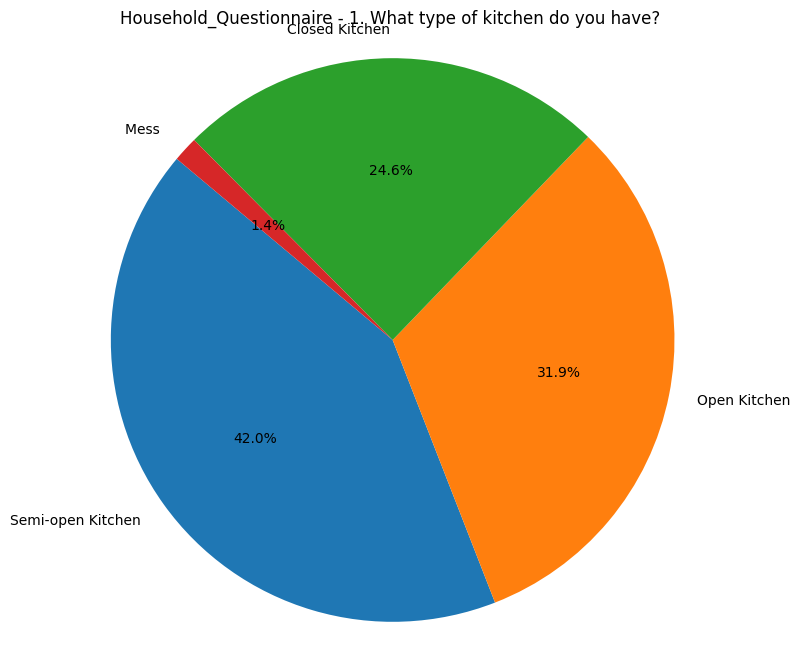

Saved pie chart for Household_Questionnaire - 2.  Is there a chimney or exhaust fan in the kitchen? 


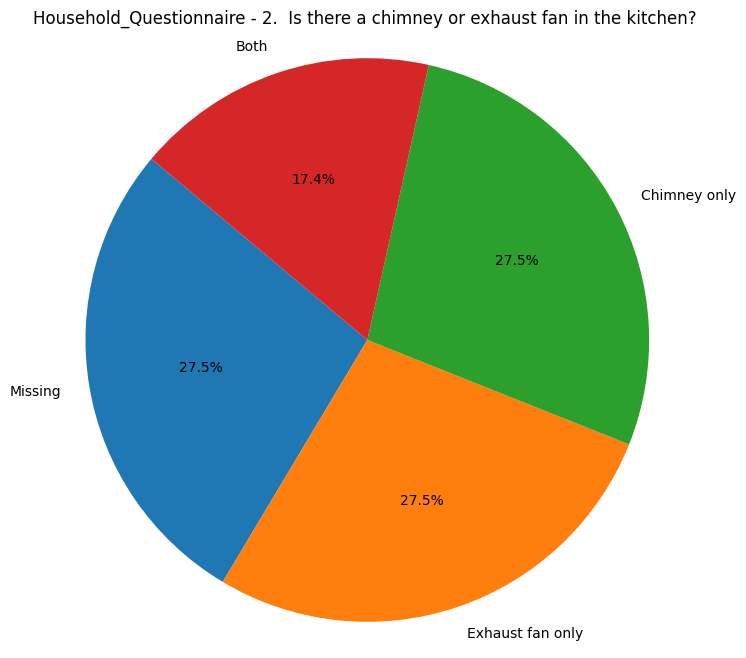

Saved pie chart for Household_Questionnaire - 3.  Is an air conditioner used in the house? 


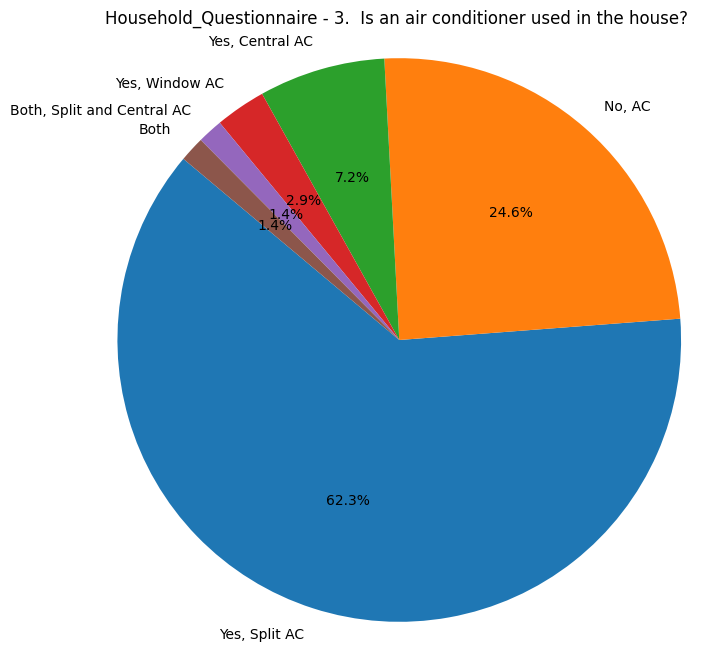

Saved pie chart for Household_Questionnaire - 4.  How would you describe the ventilation in your house? 


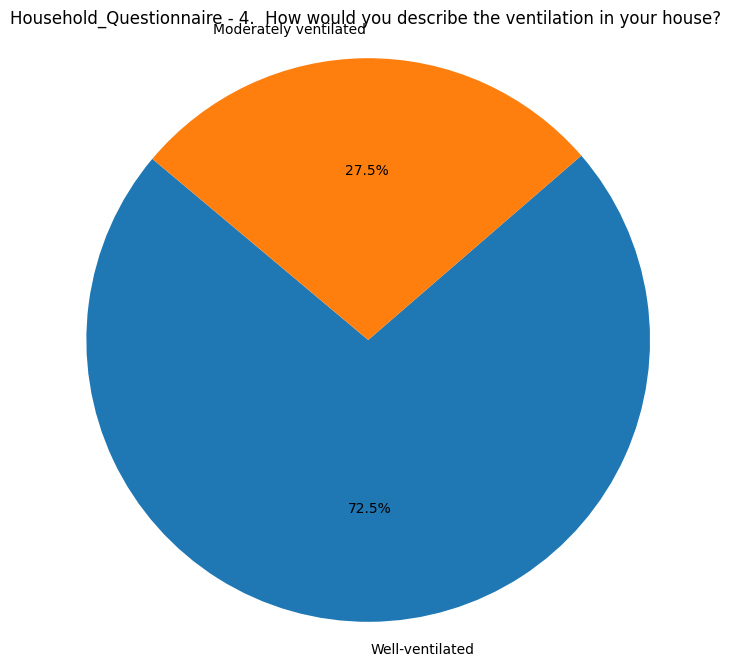

Saved pie chart for Household_Questionnaire - 5.  Are air purifiers used in any part of the house? 


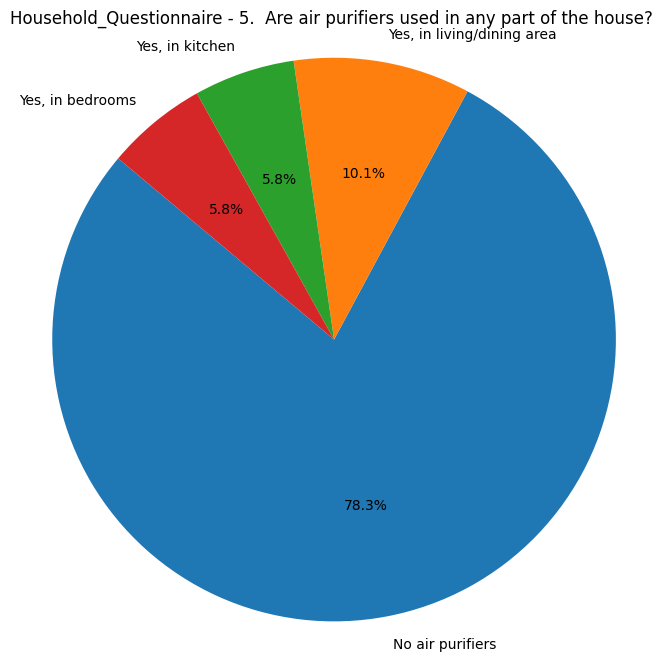

Saved pie chart for Household_Questionnaire - 6.  How often are windows kept open? 


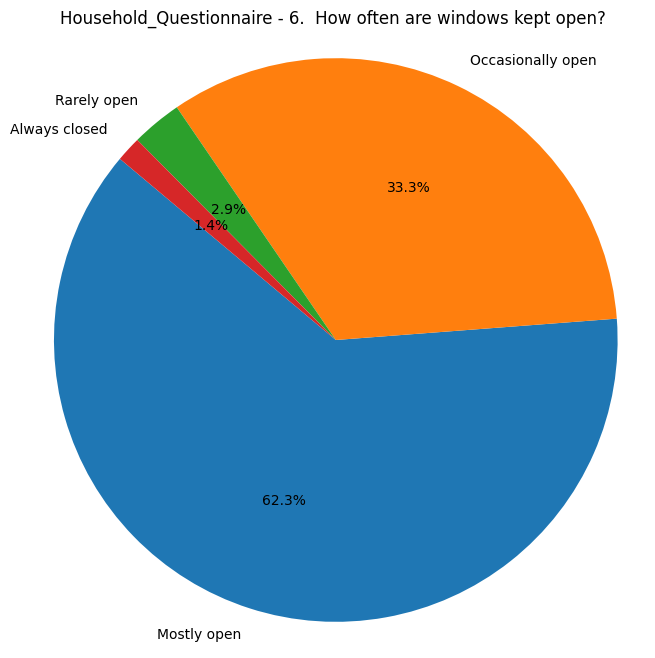

Saved pie chart for Household_Questionnaire - 7.  What do you do with windows during cooking? 


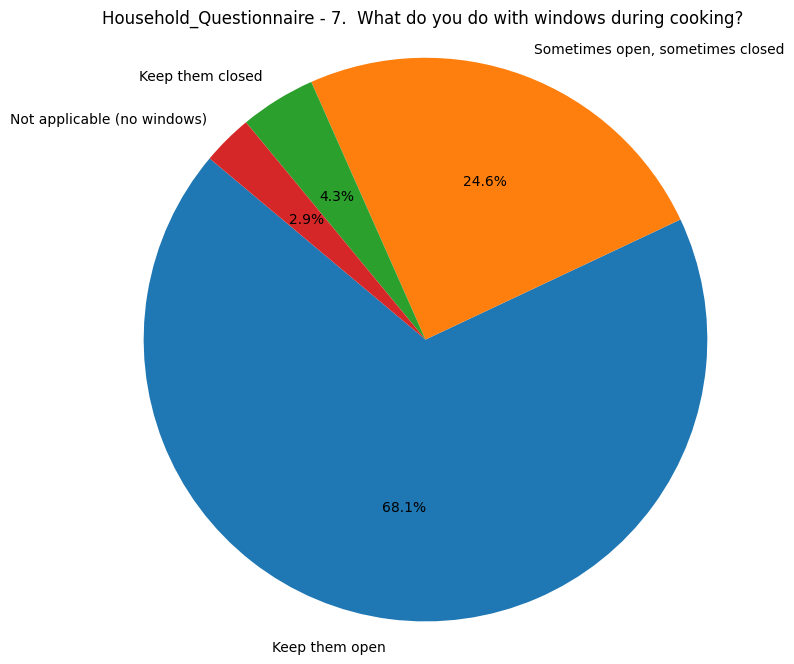

Saved pie chart for Household_Questionnaire - 8.  Window direction of the kitchen/living area: 


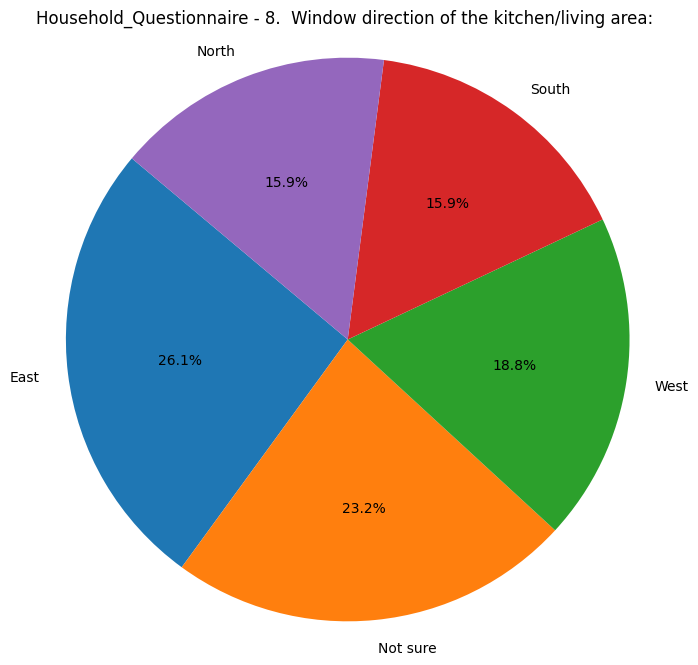

Saved pie chart for Household_Questionnaire - 9.  Number of people living in the house: 


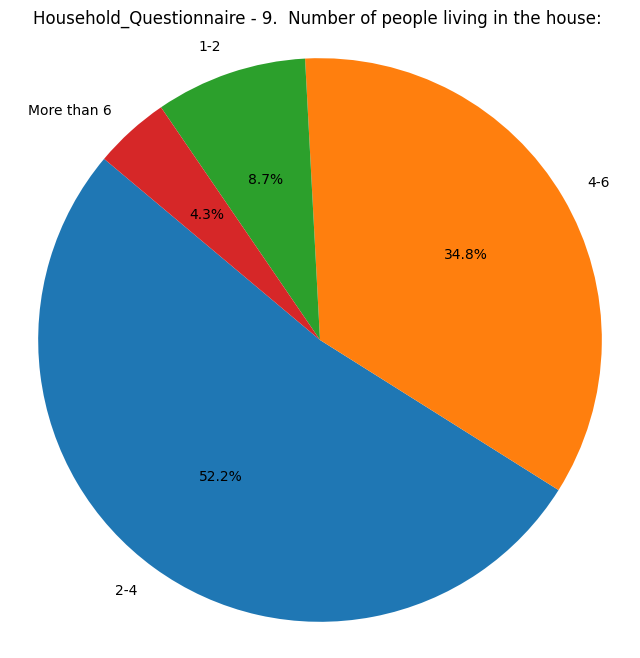

Saved pie chart for Household_Questionnaire - 10. Which floor do you live in?


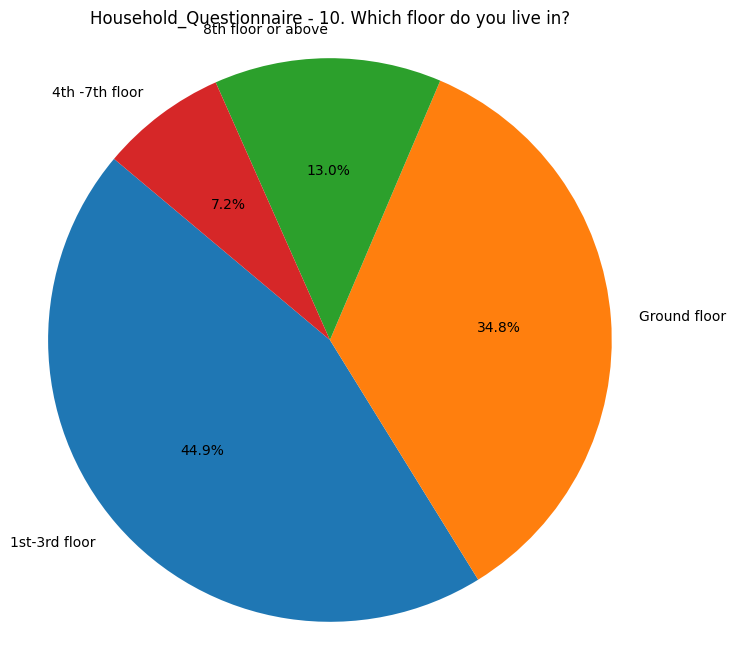

Saved pie chart for Household_Questionnaire - 11.  Type of flooring in your home: 


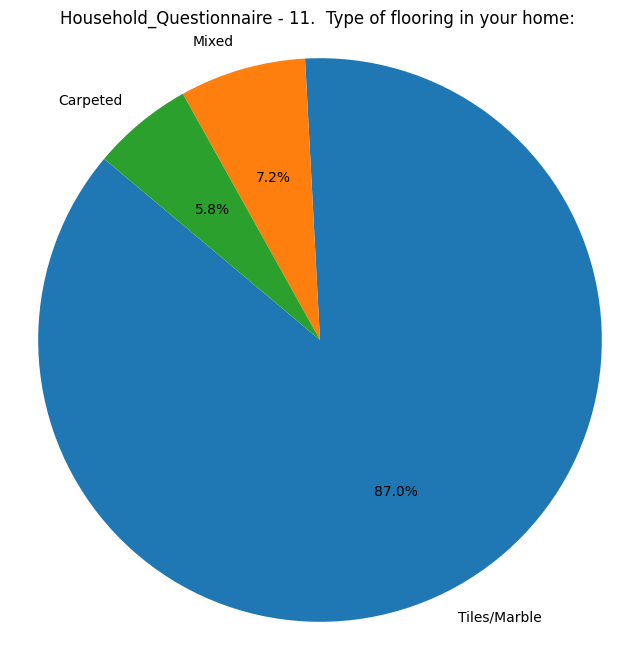

Saved pie chart for Household_Questionnaire - 12.  Immediate surroundings of the house: 


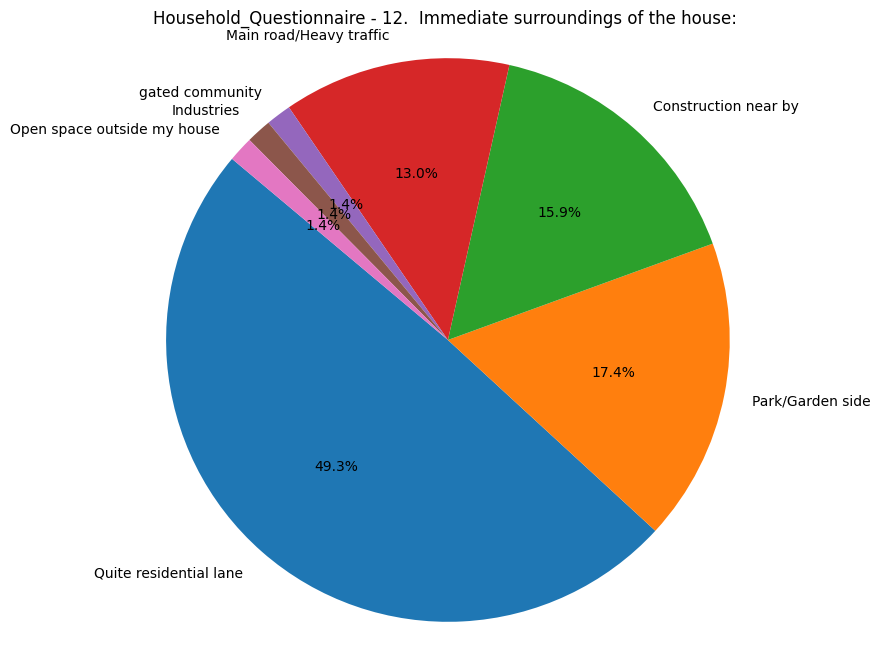

Saved pie chart for Household_Questionnaire - 13. Is greenery present around the house?


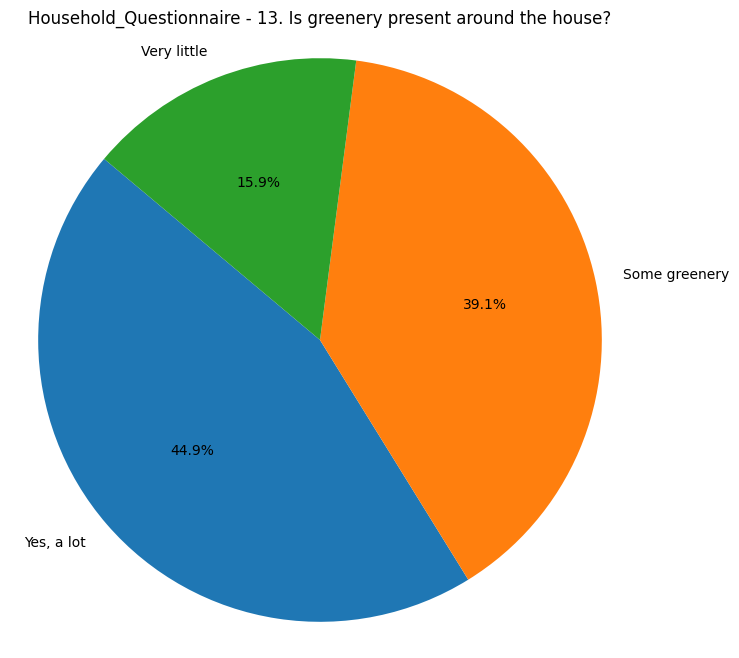

Saved pie chart for Household_Questionnaire - 1.  Primary type of fuel used for cooking: 


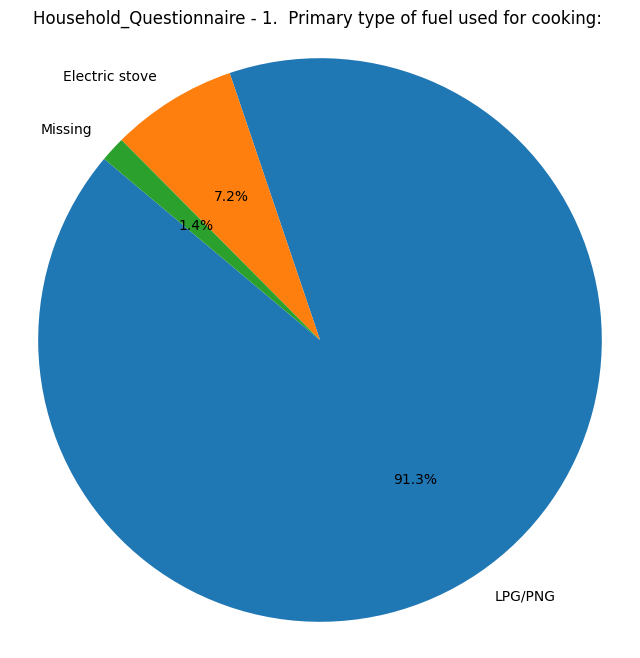

Saved pie chart for Household_Questionnaire - 2.  Type of cooking appliance used most often: 


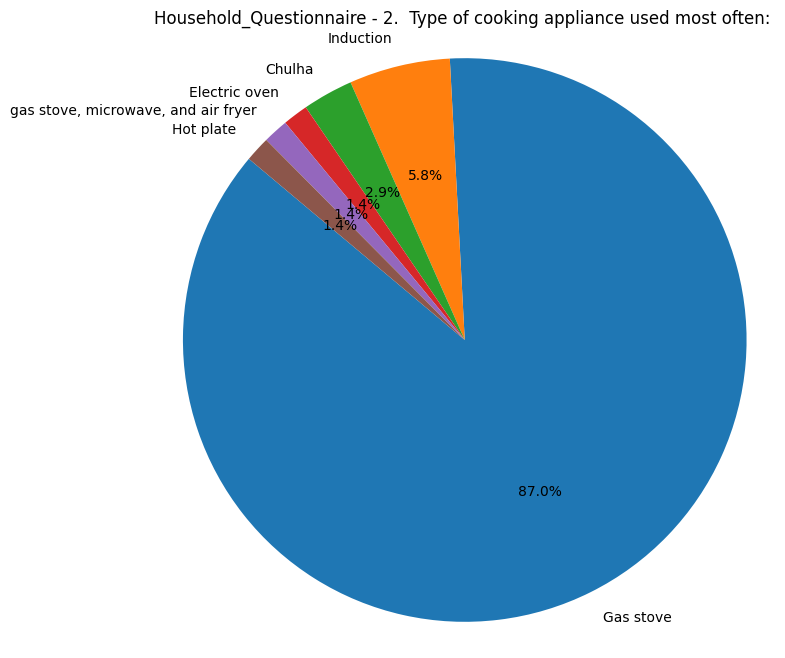

Saved pie chart for Household_Questionnaire - 3.  Common cooking methods used at home (choose the closest):  [Stir frying/ Sauteing]


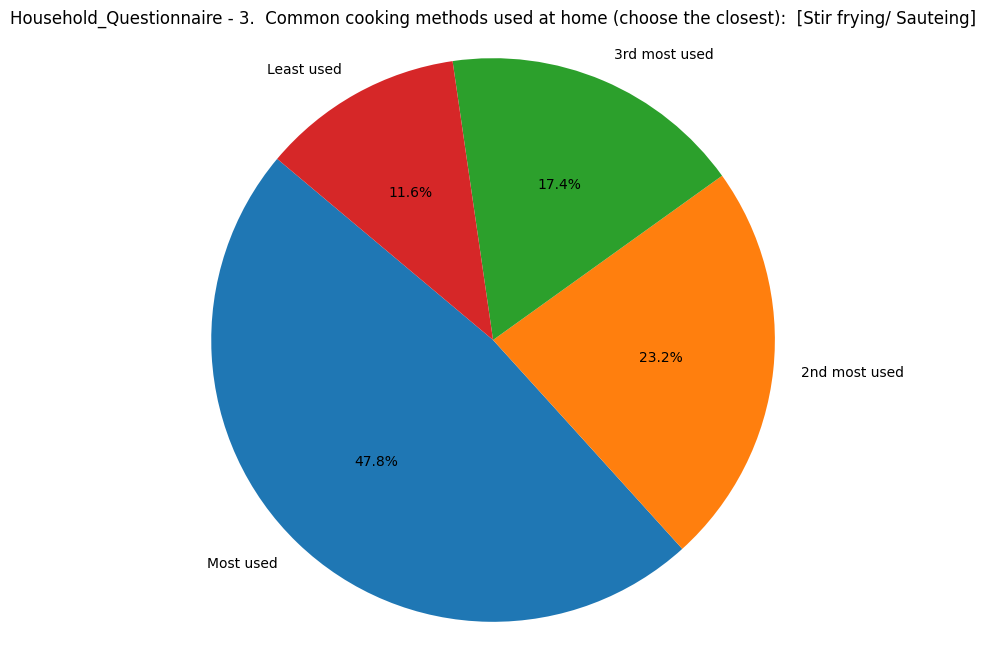

Saved pie chart for Household_Questionnaire - 3.  Common cooking methods used at home (choose the closest):  [Deep frying/ Shallow frying]


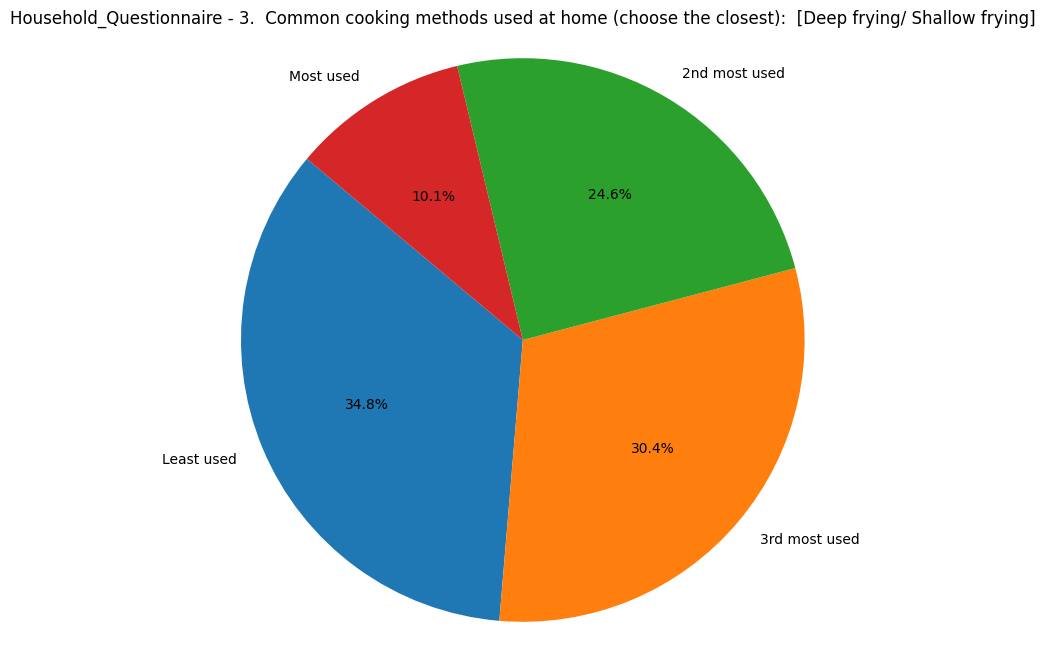

Saved pie chart for Household_Questionnaire - 3.  Common cooking methods used at home (choose the closest):  [Boiling/ Steaming]


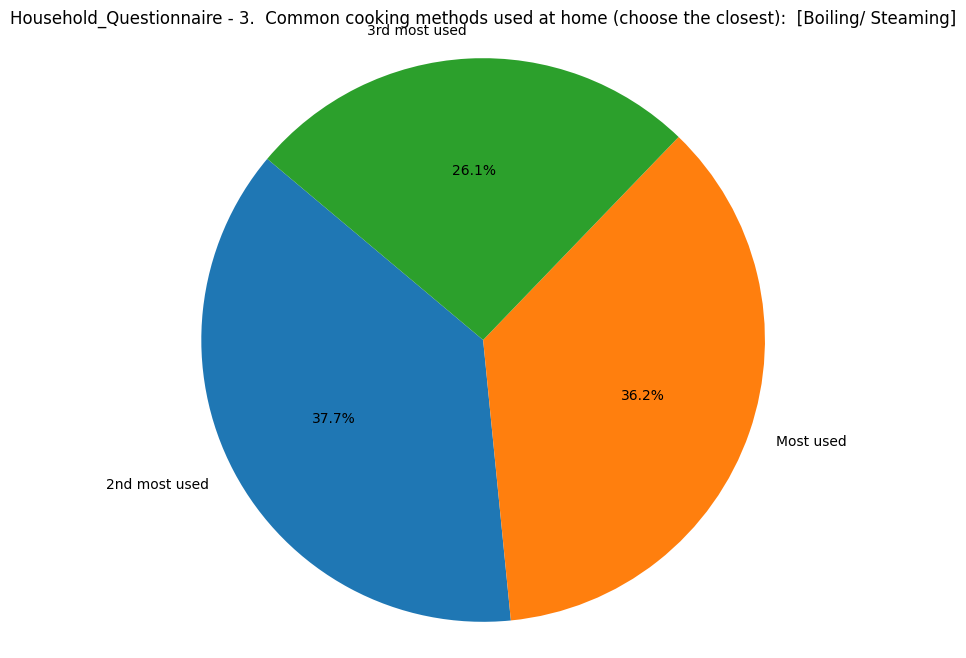

Saved pie chart for Household_Questionnaire - 3.  Common cooking methods used at home (choose the closest):  [Baking/ Grilling]


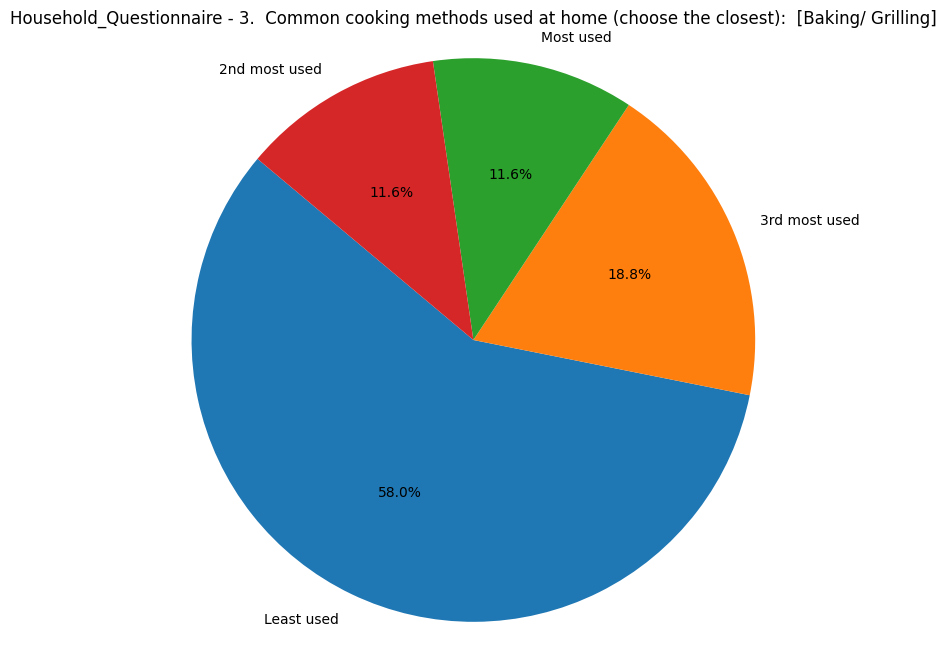

Saved pie chart for Household_Questionnaire - 4.  How frequently does deep frying happen at home? 


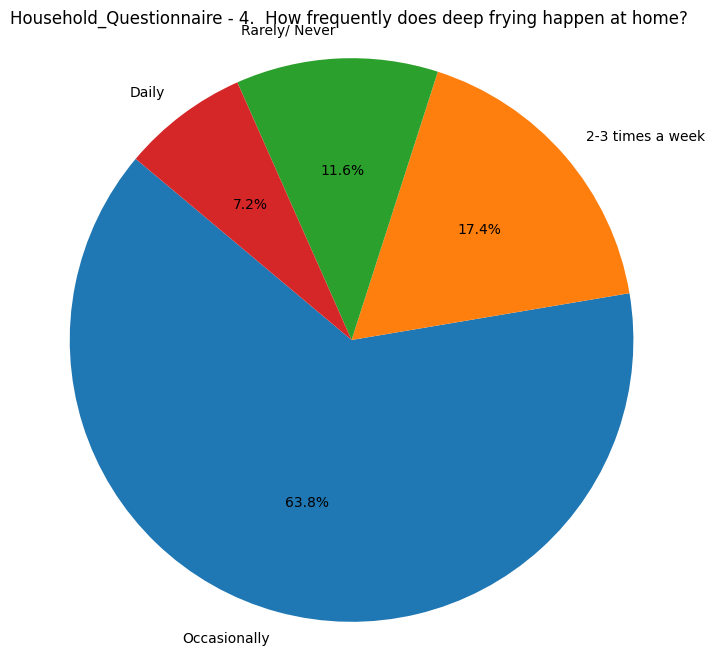

Saved pie chart for Household_Questionnaire - 5.  Type of cooking oil used most often at home: 


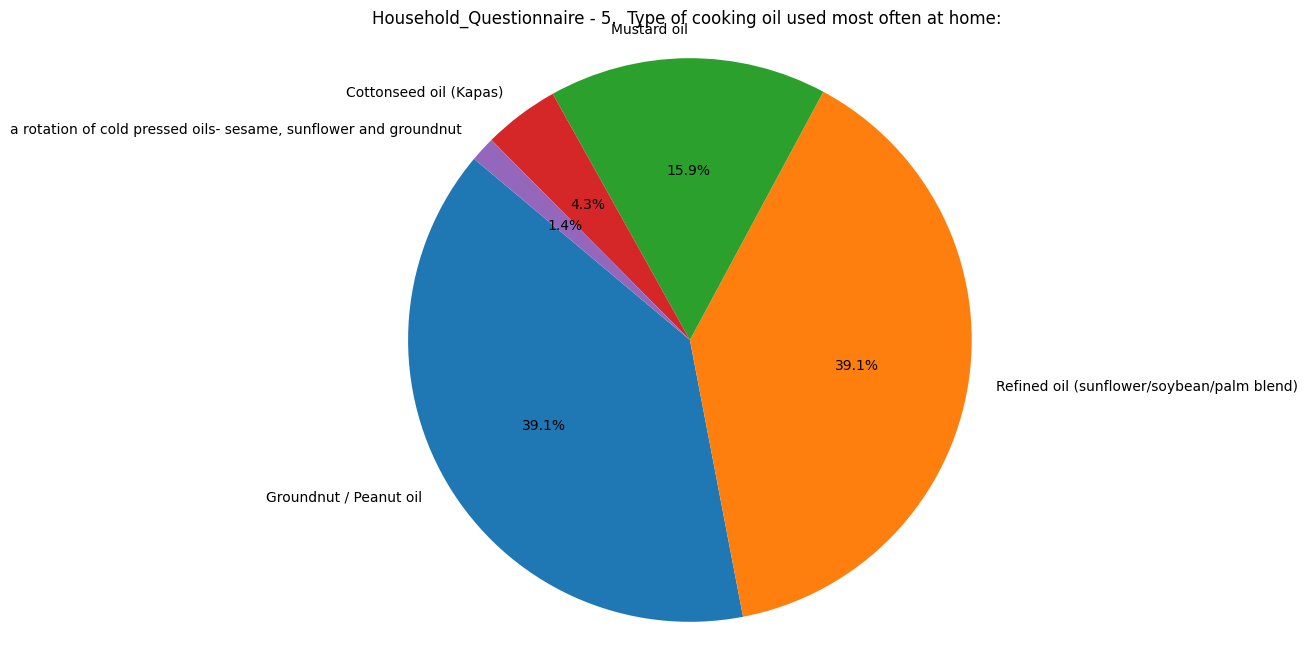

Saved pie chart for Household_Questionnaire - 6.  Do you use incense sticks, camphor, or dhoop during prayers? 


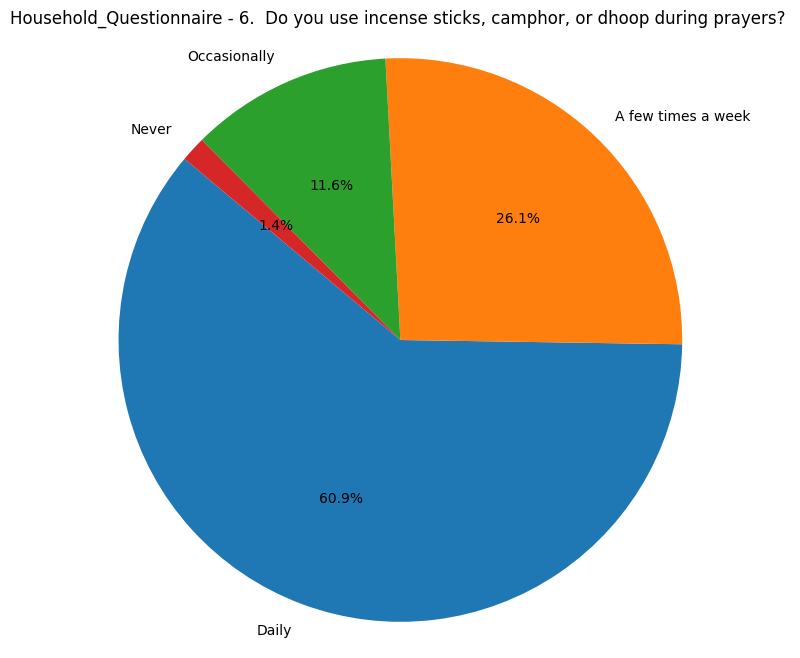

Saved pie chart for Household_Questionnaire - 1.  Does anyone smoke in or around the house? 


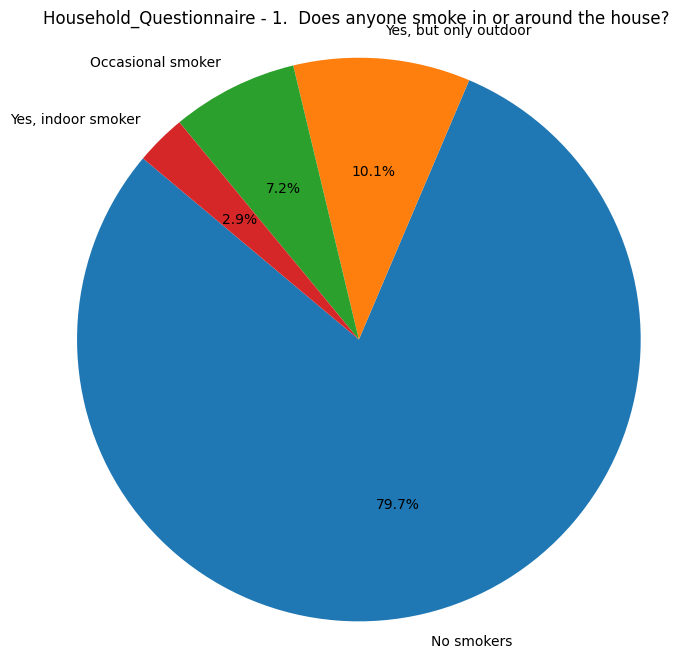

Saved pie chart for Household_Questionnaire - 2.  Cleaning method used most often: 


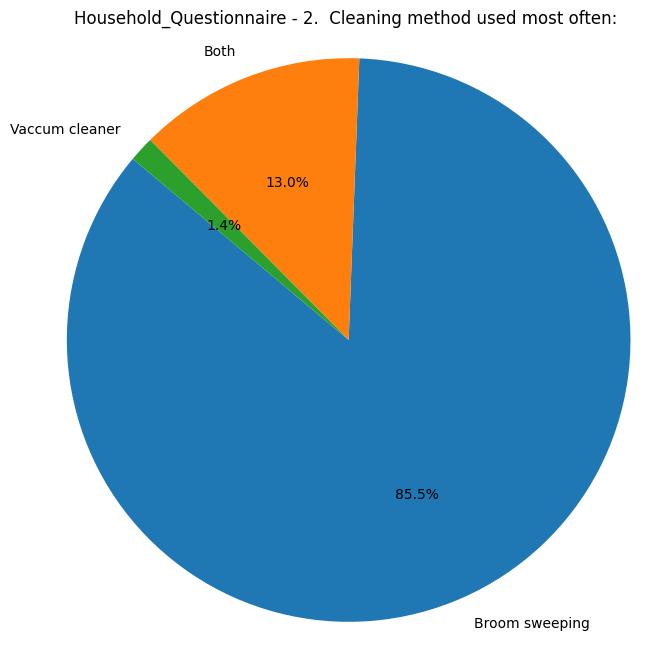

Saved pie chart for Household_Questionnaire - 3.  Products commonly used for mopping / cleaning floors: 


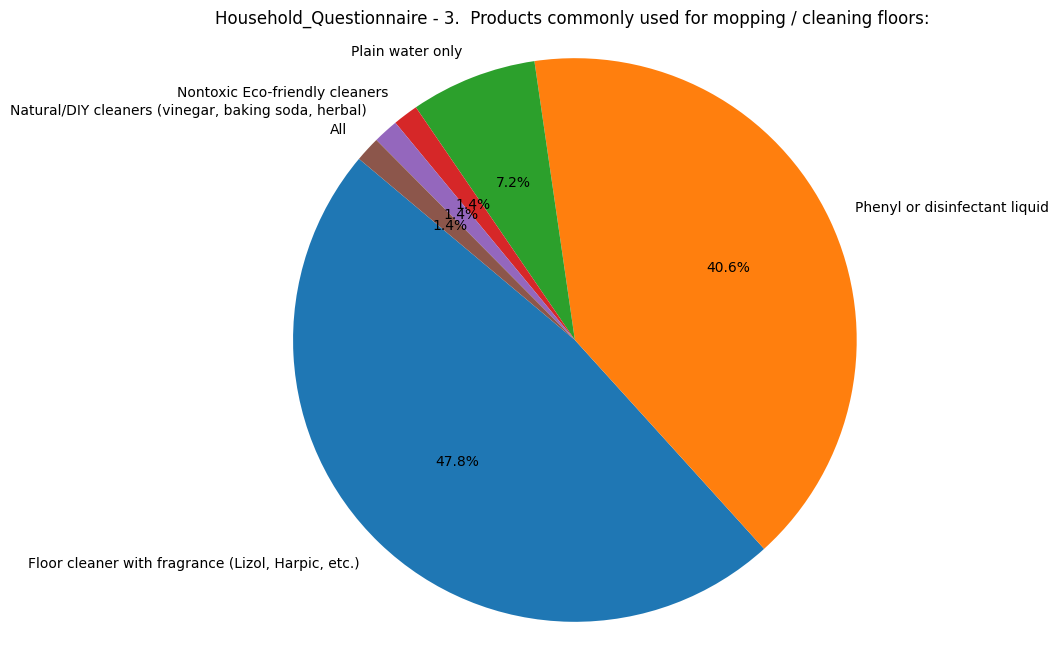

Saved pie chart for Household_Questionnaire - 4.  Preferred time of cleaning: 


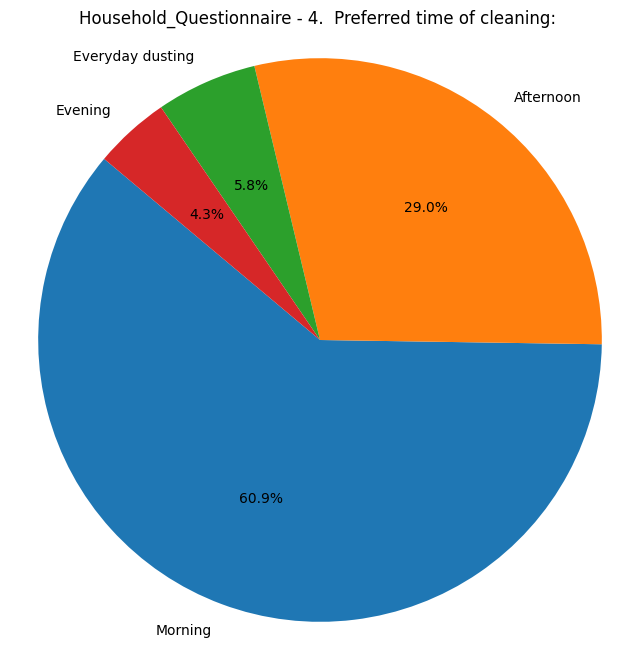

Saved pie chart for Household_Questionnaire - 5.  Do you use any of the following?


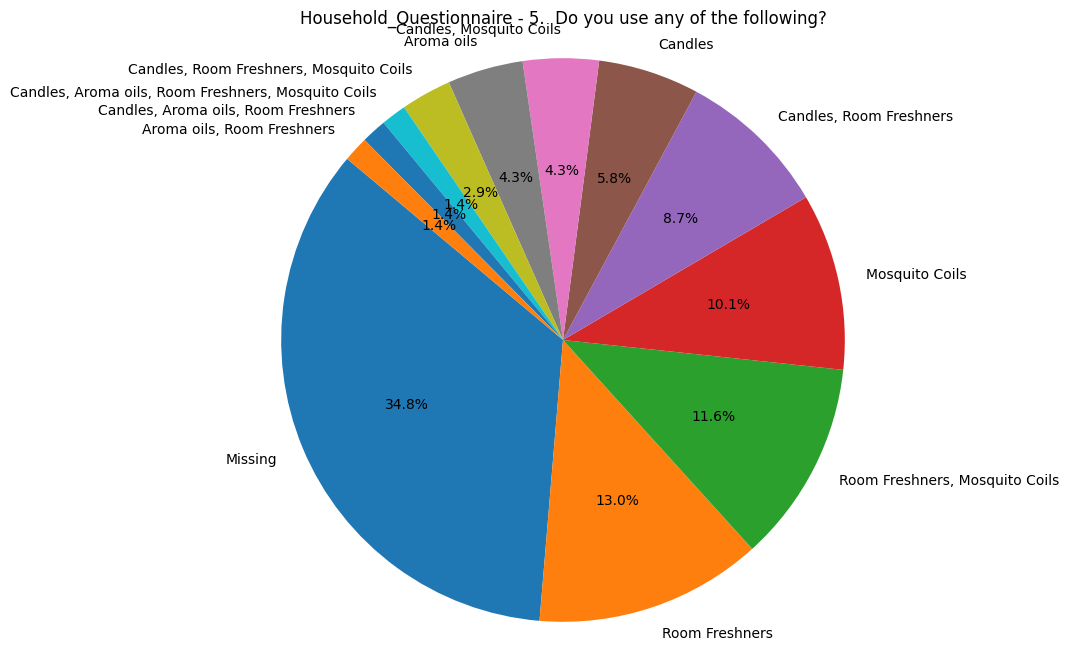

Saved pie chart for Household_Questionnaire - 1.  Approximate dimensions of the kitchen: 


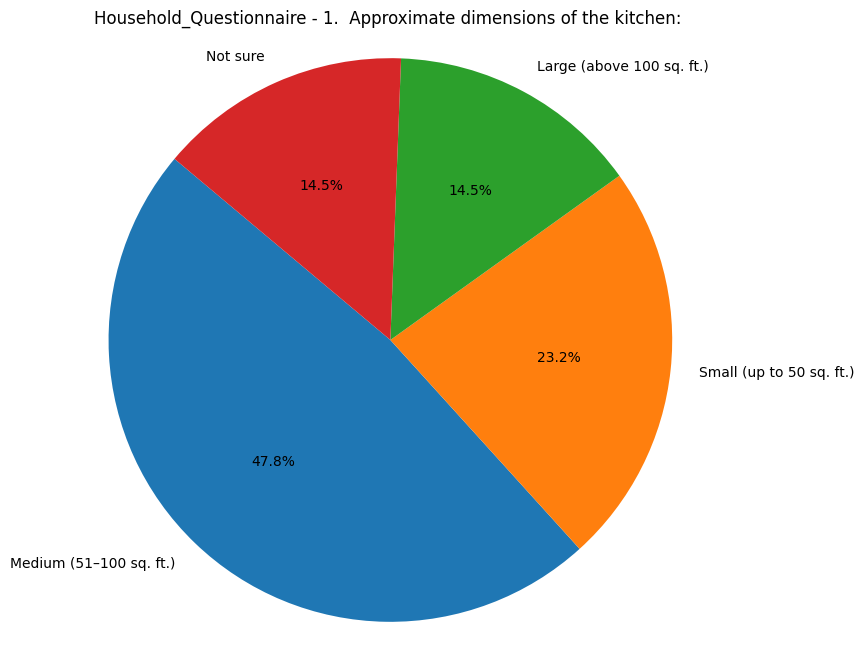

Saved pie chart for Household_Questionnaire - 2. Approximate distance between kitchen and living room/hall: 


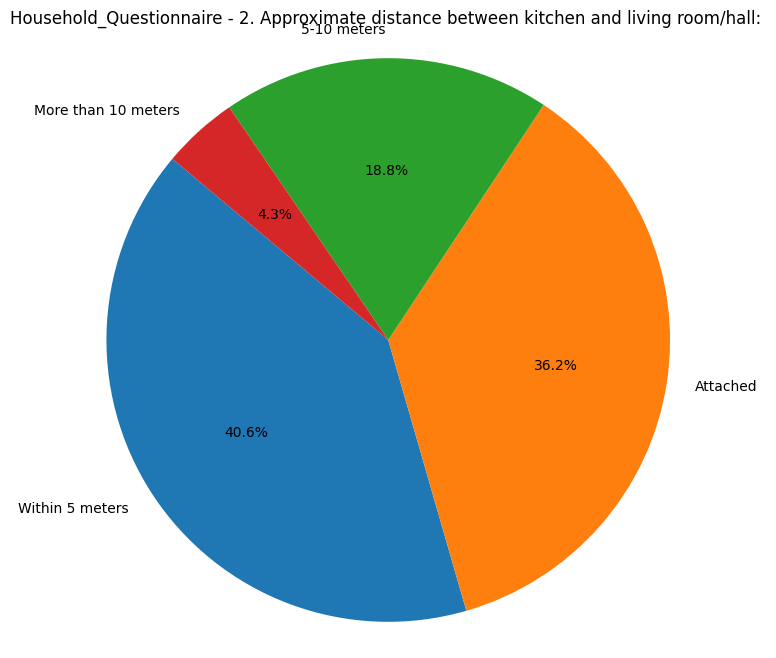

Saved pie chart for Household_Questionnaire - 3. Distance between kitchen and bedrooms: 


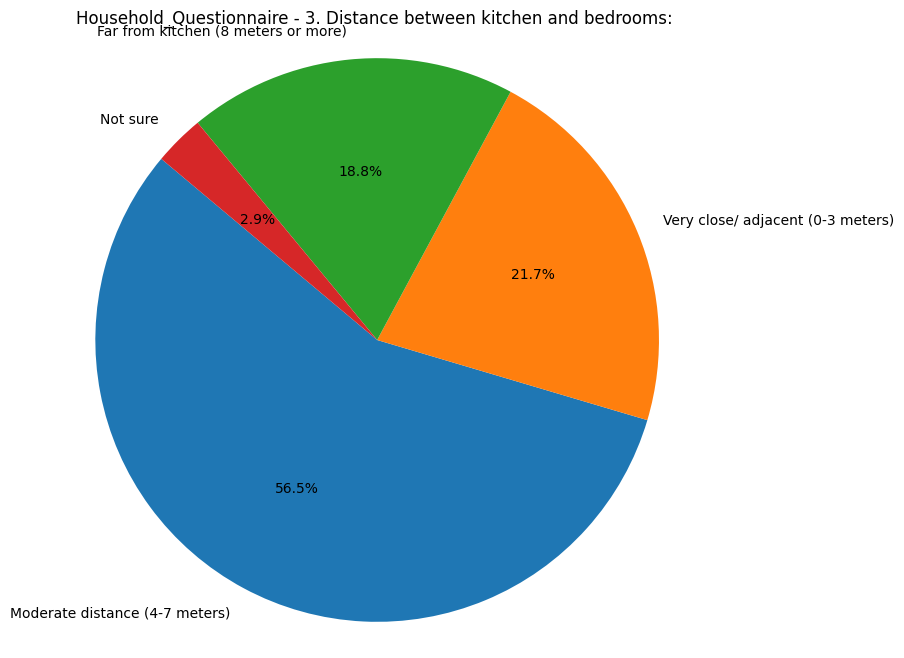

Saved pie chart for Household_Questionnaire - 4.  How frequently is the main door kept open? 


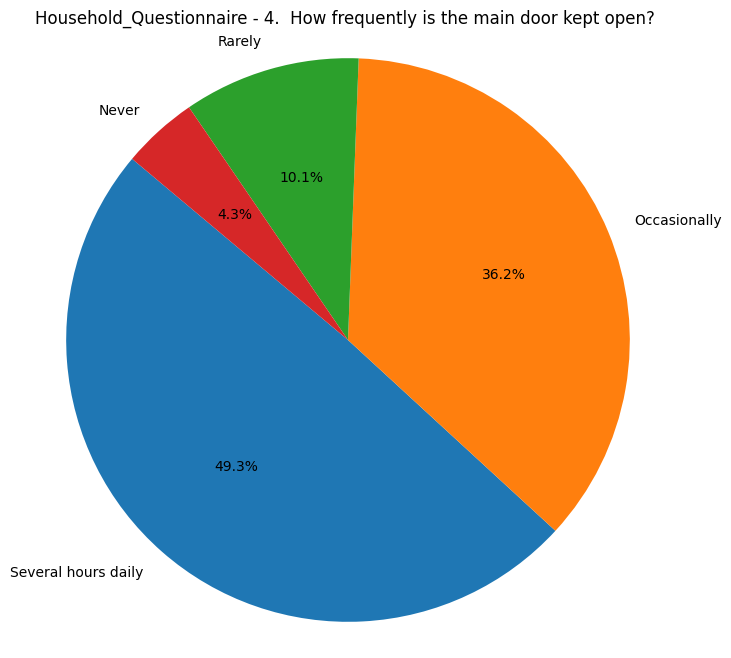

Saved pie chart for Household_Questionnaire - 5. Presence of indoor plants:


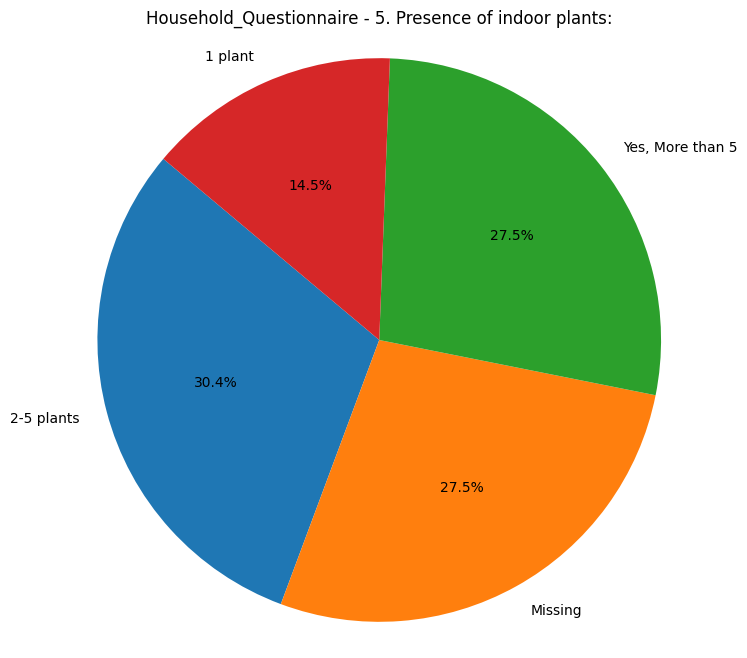

Saved pie chart for Household_Questionnaire - What type of house do you live in?


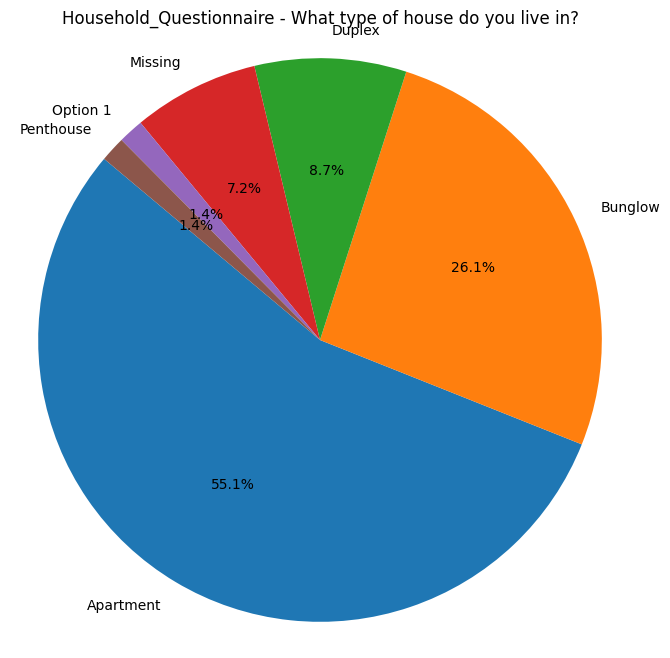

Saved pie chart for Household_Questionnaire - I confirm that I have voluntarily participated in this survey and understand that my responses will be kept confidential and used only for academic research purposes.


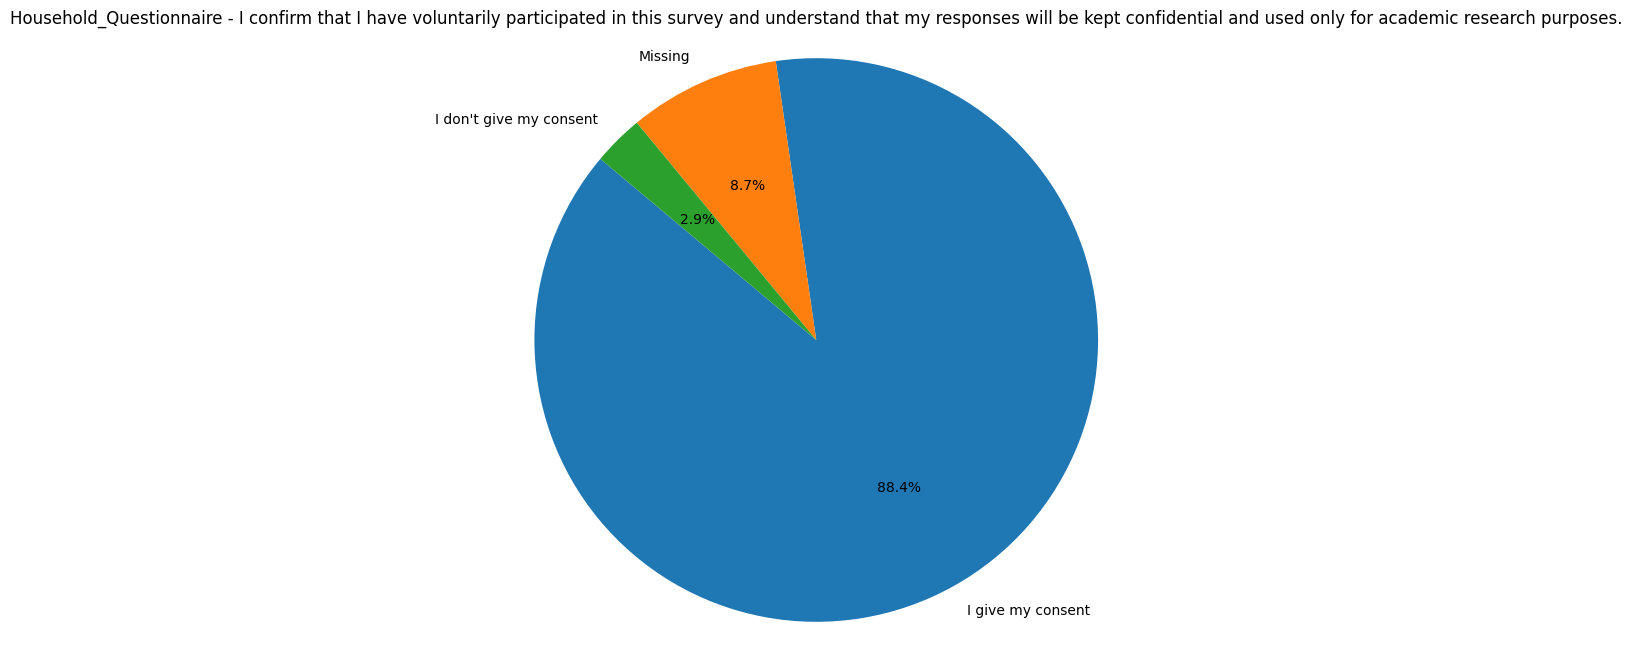

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 1. How often do you or your family experience breathing discomfort at home?



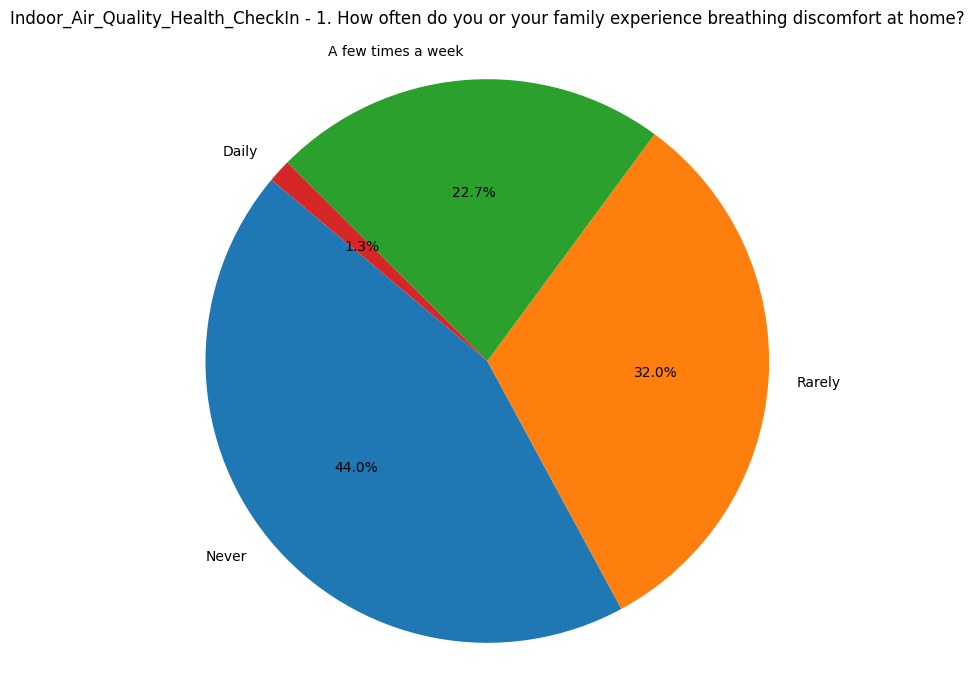

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 2. Does anyone in the household have dust or smoke-related sensitivity?


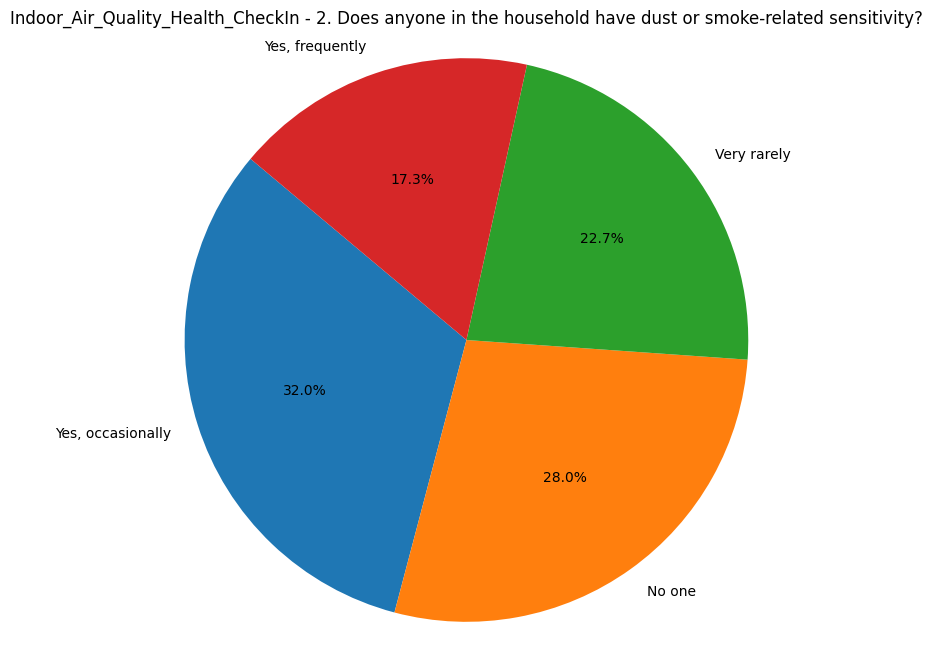

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 3. Has anyone at home noticed more coughing/sneezing on days when cooking or cleaning activity is higher?


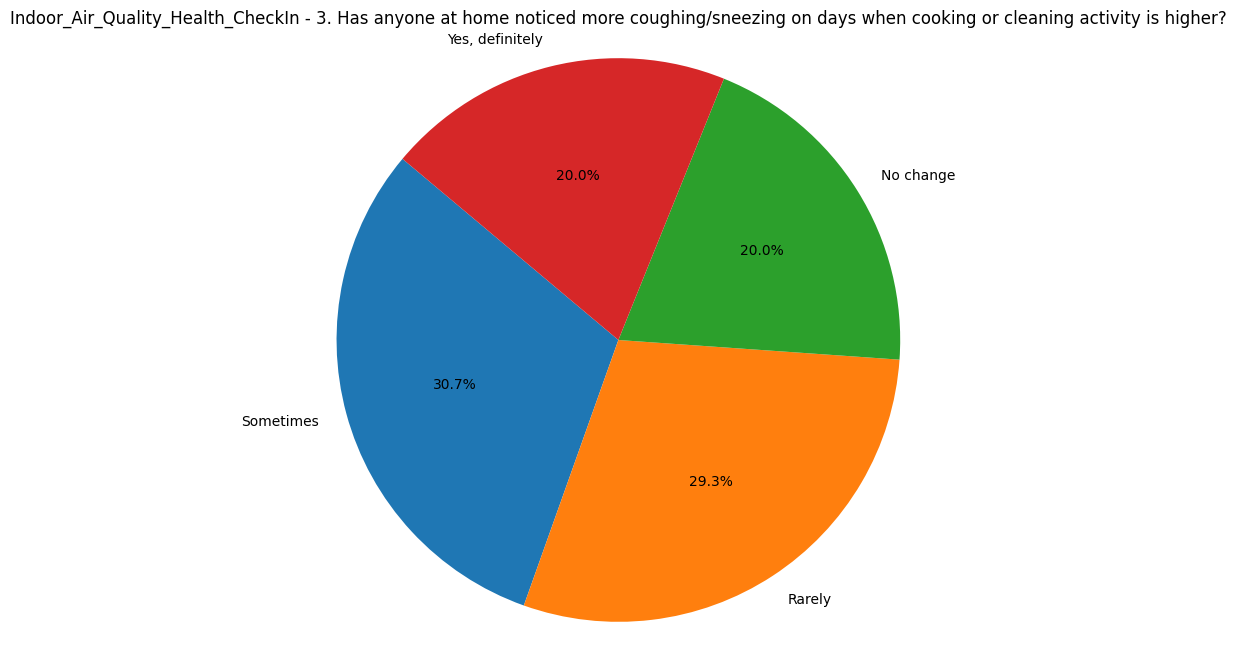

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 4. Do you usually notice any smell, smoke, or haze lingering in the house after cooking?


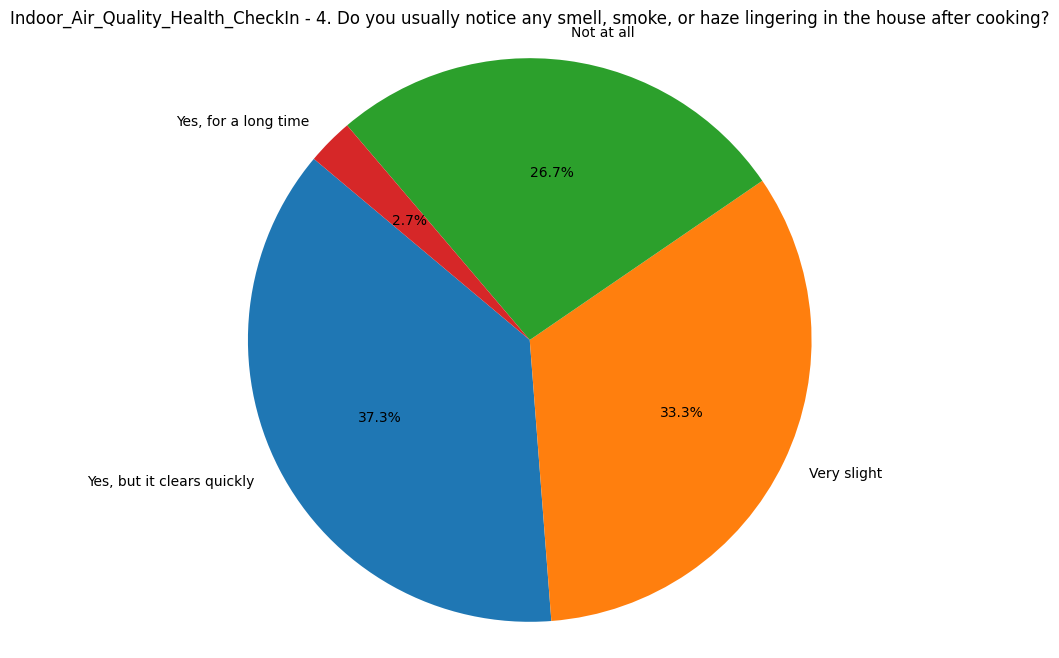

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 5. Does anyone at home experience headaches related to indoor environment or smells?


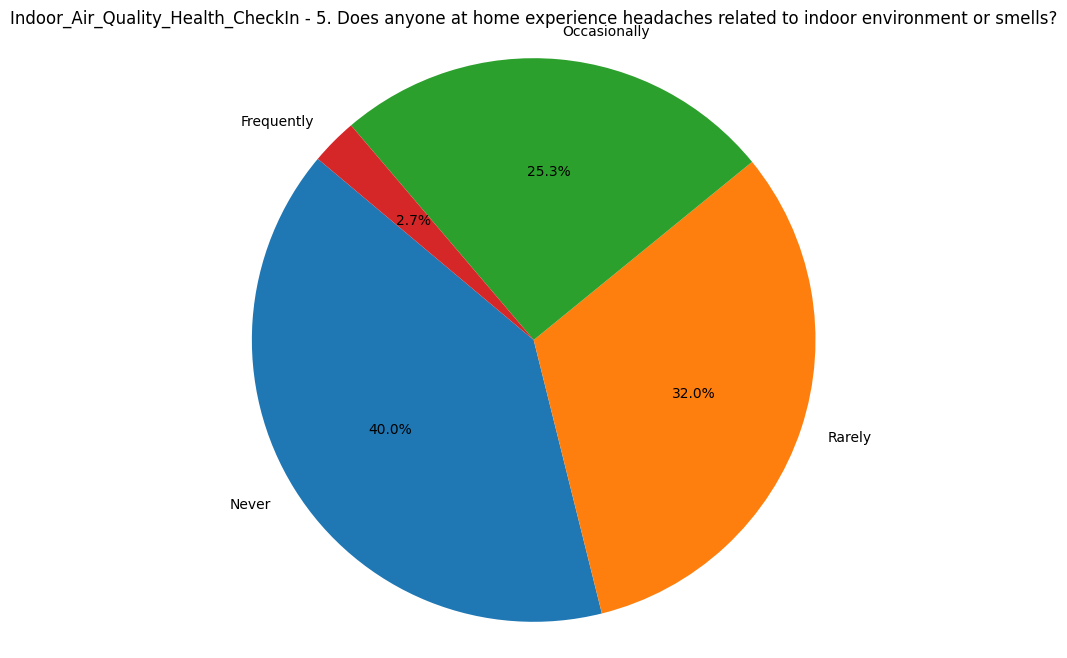

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 6. Do you think outdoor pollution affects the air inside your home?


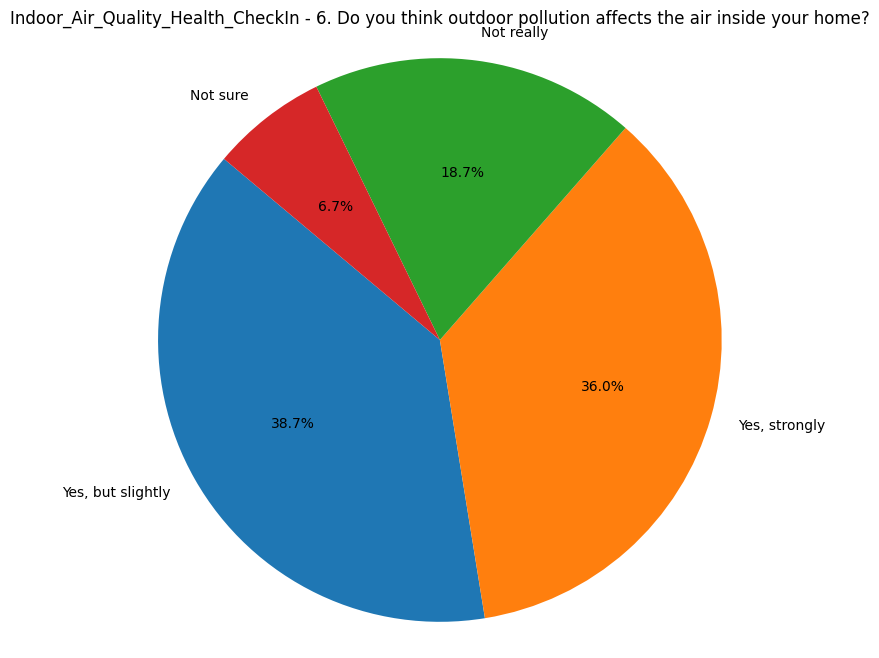

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 7. On most days, how would you describe the indoor air freshness?


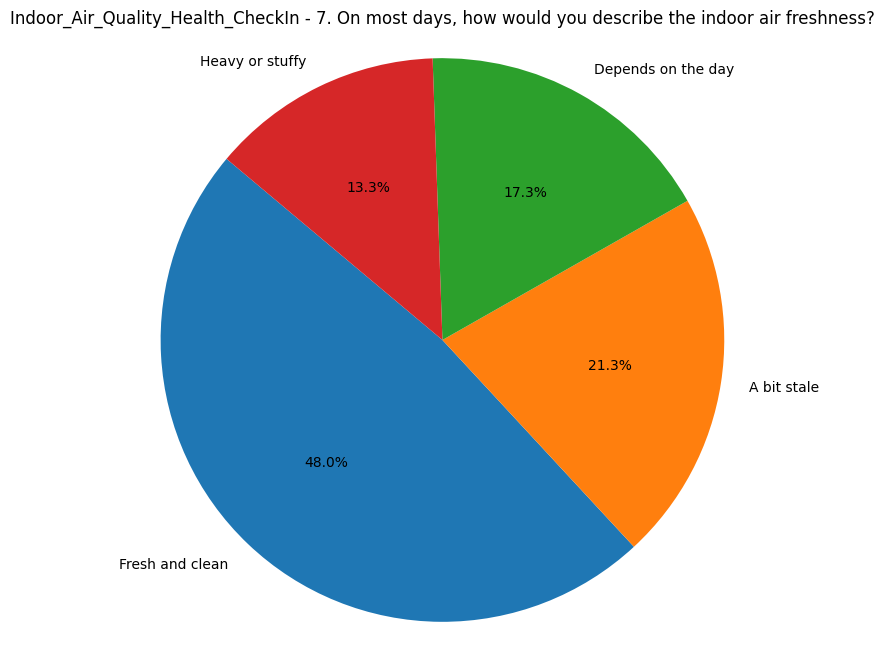

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 8. Does anyone at home have pre-existing respiratory conditions (asthma, sinus issues, allergies, COPD)?


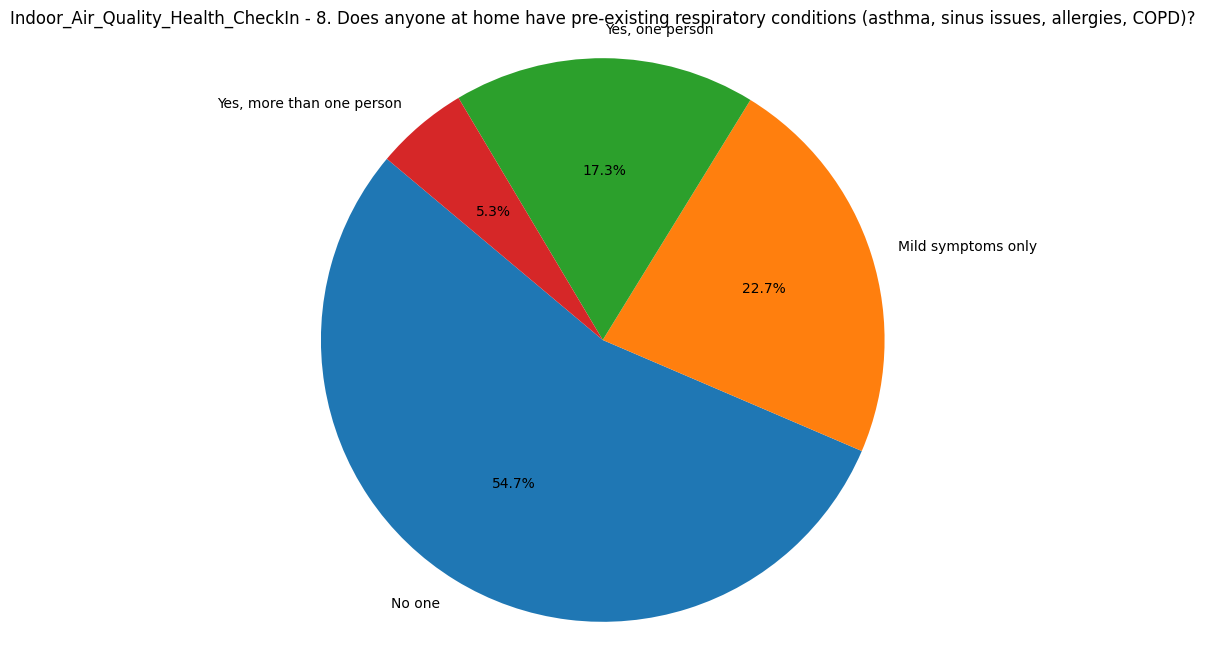

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 9. Have you ever felt eye irritation while being indoors?


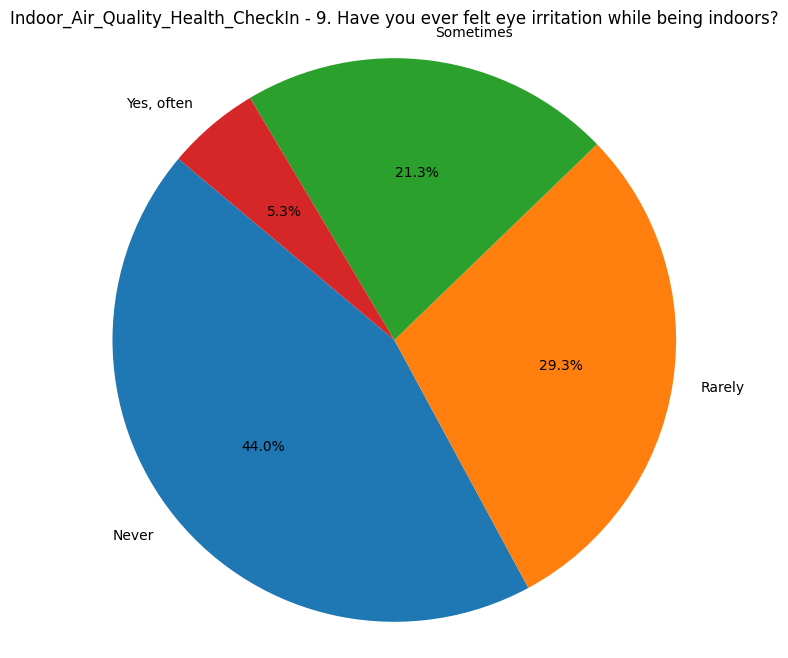

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 10. On days when the house feels stuffy, what do you usually do?


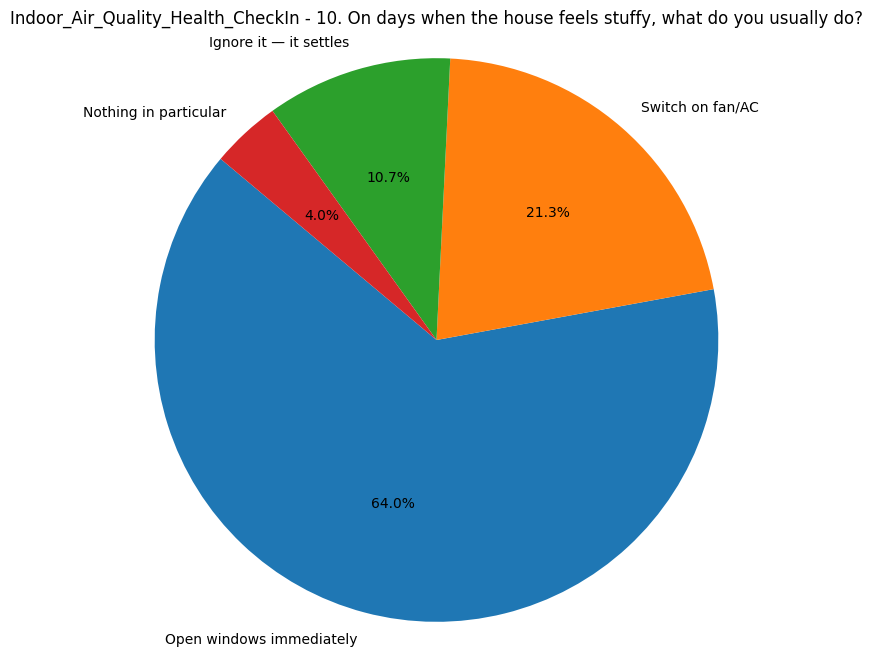

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 11. How often do you notice dust settling on surfaces at home?


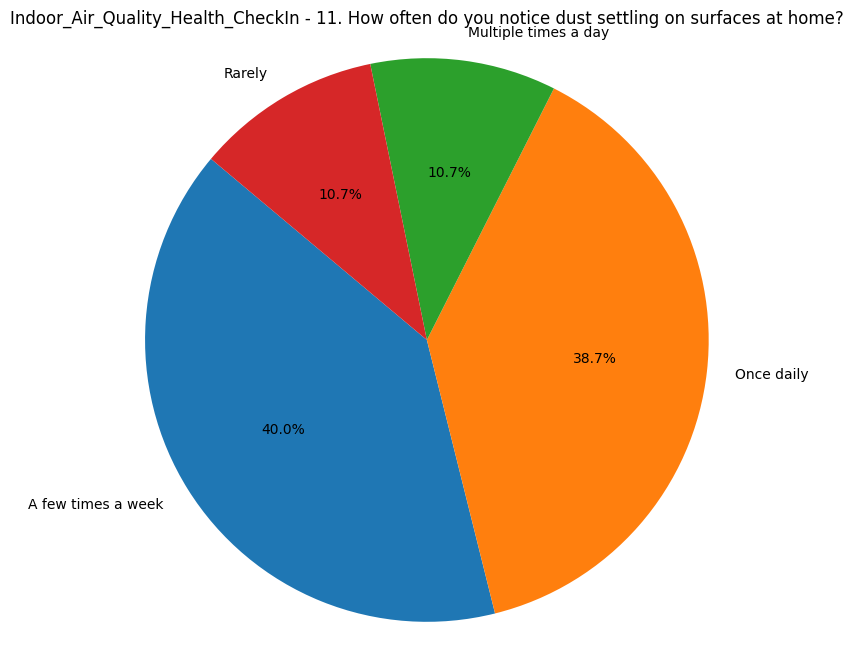

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 12. Has anyone in your household faced sleep disturbances due to air quality or smell?


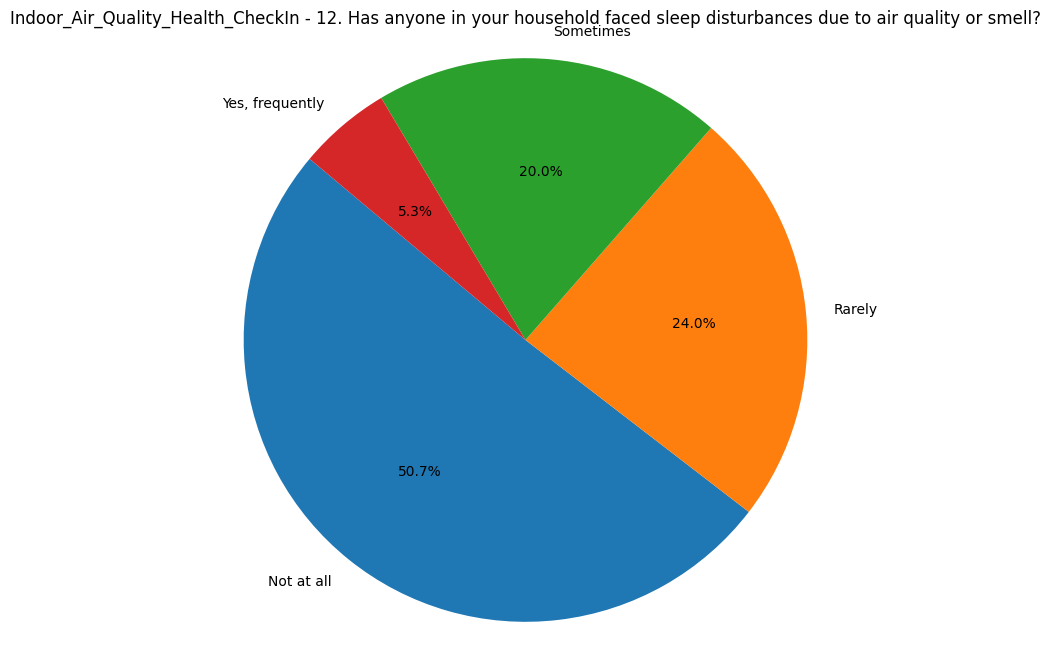

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 13. Do you feel that indoor activities increase pollution levels at home?


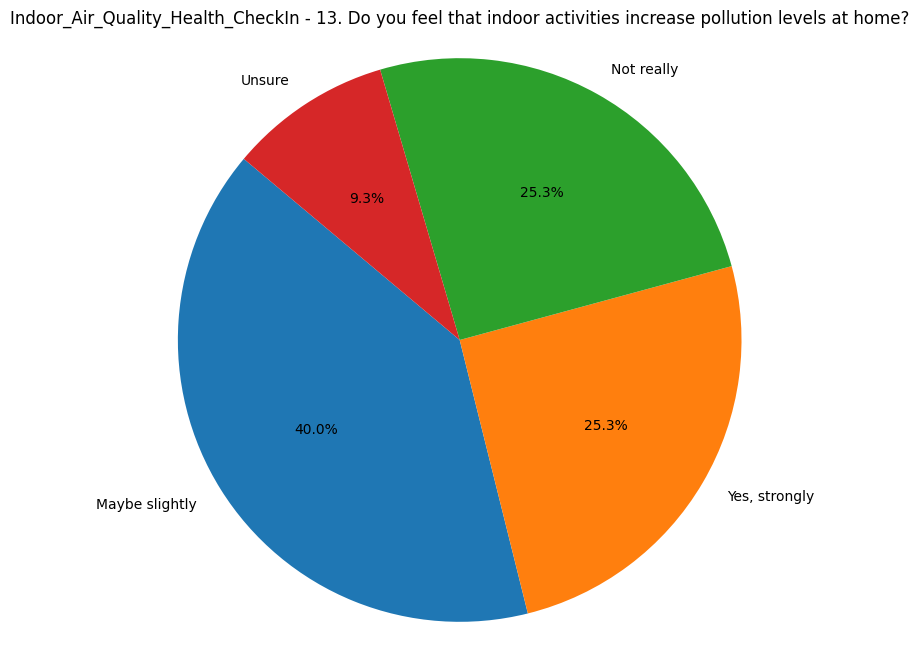

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 14. On average, how aware do you feel about the air quality inside your home?


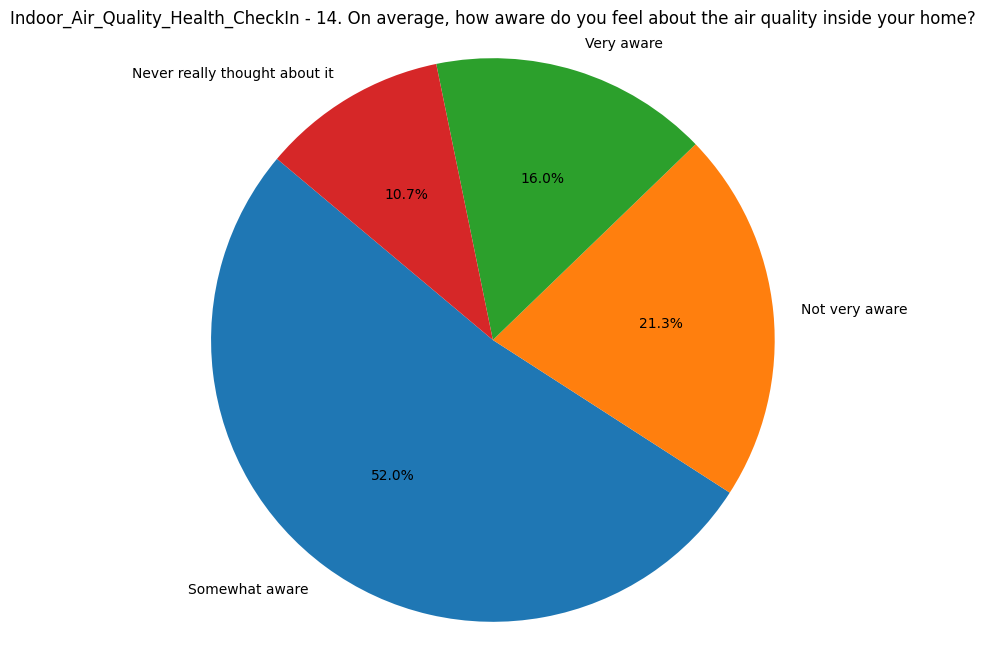

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - 15. Do you believe your household’s daily habits influence your indoor air quality?


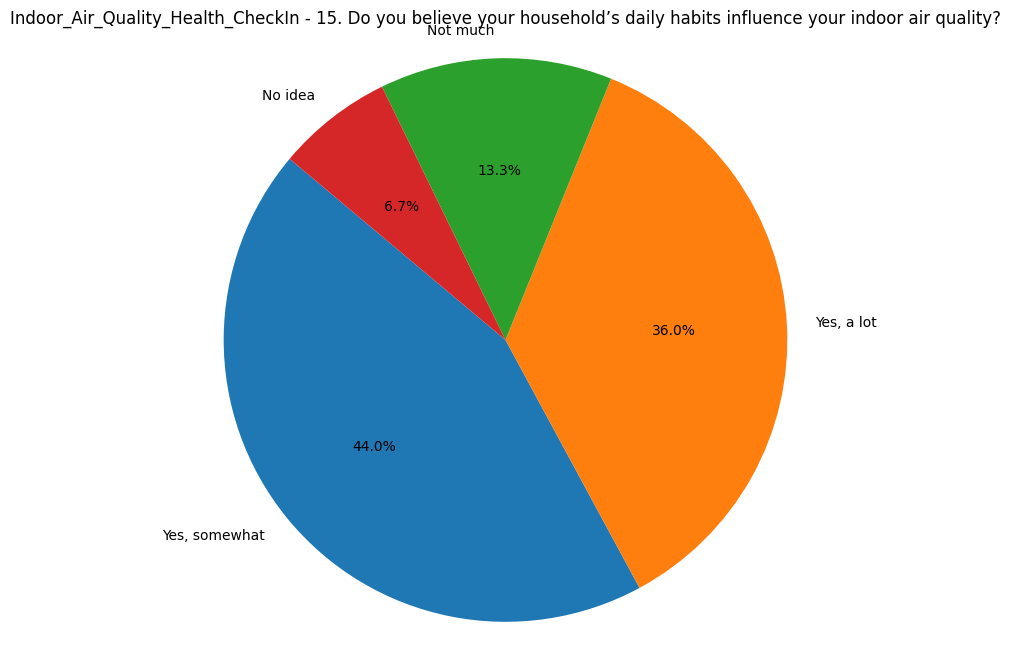

Saved pie chart for Indoor_Air_Quality_Health_CheckIn - I confirm that I have voluntarily participated in this survey and understand that my responses will be kept confidential and used only for academic research purposes.


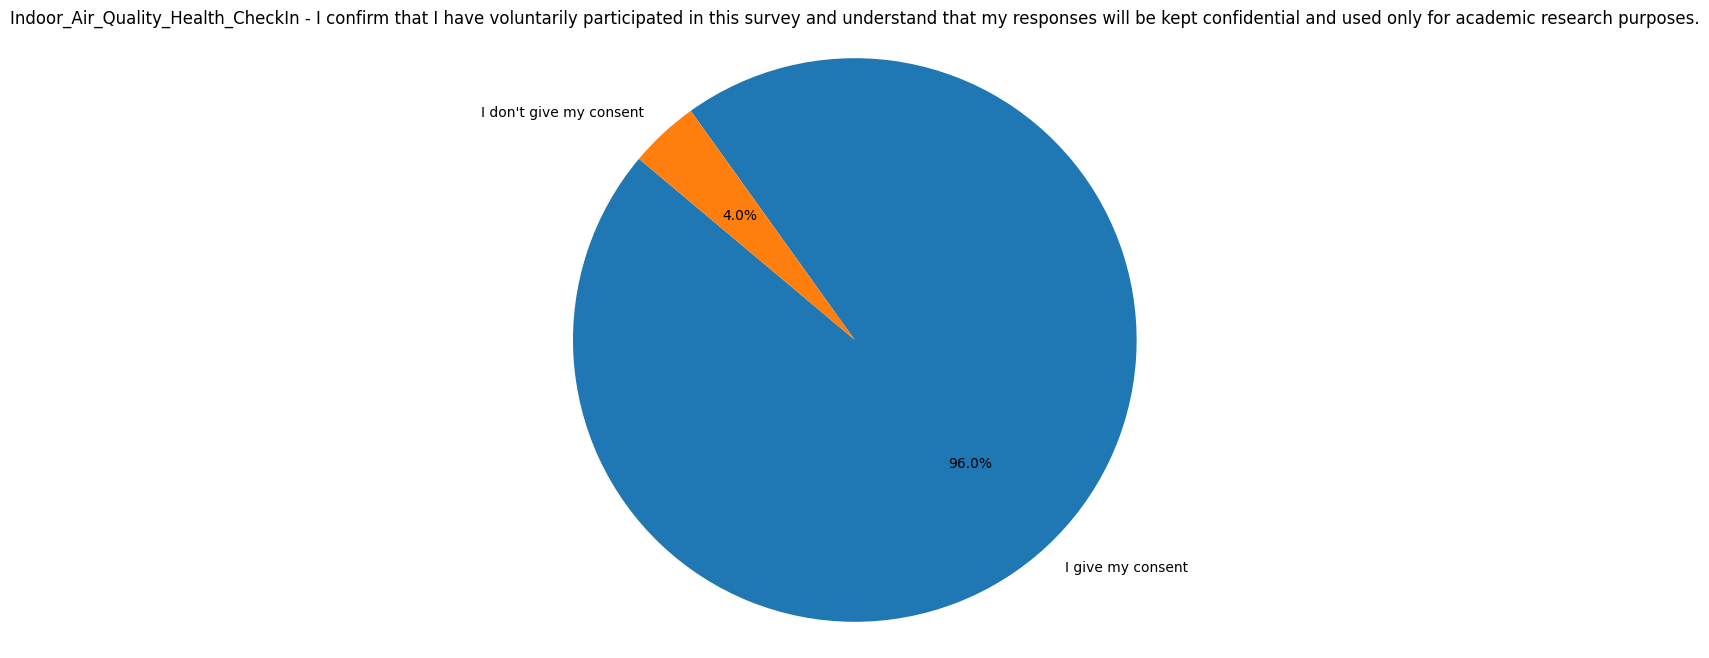

In [4]:
make_pi_plots(households, "Household_Questionnaire")
make_pi_plots(indoor_air_quality_health, "Indoor_Air_Quality_Health_CheckIn")